In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("26-customer_data.csv")

In [4]:
#Annual Income: Yıllık gelir
# Spending Score: Harcama puanı
df.head()

,Annual_Income,Spending_Score
0,-5.772478,-4.818216
1,6.768246,-5.424570
2,5.796159,-6.239967
3,7.096022,-5.272612
4,-5.725561,-9.316889


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Annual_Income   1499 non-null   float64
 1   Spending_Score  1499 non-null   float64
dtypes: float64(2)
memory usage: 23.5 KB


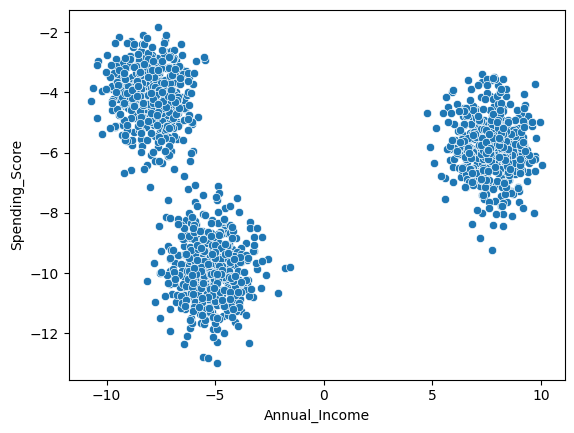

In [6]:
sns.scatterplot(data=df, x="Annual_Income", y="Spending_Score")
plt.show()

In [7]:
# Burada bağımlı bir özelliğimiz olmadığı için y'yi kullanmayacağız.
# Modelin tamamını df ile eğitebiliriz veya modelimizi test etmek için sadece eğitim-test ayrımı yapabiliriz.
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(df, test_size=0.3, random_state=15)

In [8]:
X_train


,Annual_Income,Spending_Score
482,-7.486110,-3.583399
235,-7.552626,-4.381446
419,-4.462203,-9.309096
1068,-3.995774,-7.509662
369,-4.208993,-10.680397
...,...,...
667,-6.734875,-5.107626
156,-8.236823,-3.127431
384,-7.744180,-3.563590
645,-6.151325,-9.263209


In [9]:
# KNN, K-Means gibi algoritmalarda standart ölçekleyici yerine normalizasyon kullanabiliriz.
# Sinir ağlarında veya verileri normalize edip 0-1 arasına yerleştirmek istediğimizde.
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [10]:
from sklearn.cluster import KMeans

In [11]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11): #try k numbers from 1 to 11
    kmeans=KMeans(n_clusters=k,init="k-means++") 
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [12]:
wcss

[174.9137775010774,
 102.38372523778159,
 10.554314128405089,
 8.903968739021408,
 8.284103714653607,
 6.66737779226435,
 5.134591037469558,
 4.463937741455512,
 3.8976381122081727,
 3.630066443752206]

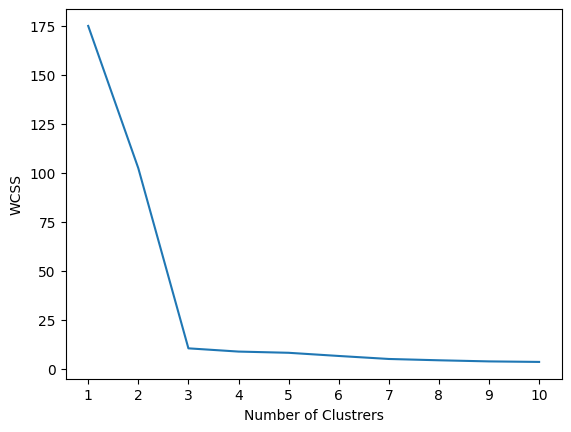

In [13]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [14]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [15]:
kmeans.fit(X_train_scaled)

KMeans(n_clusters=3)

In [16]:
y_pred=kmeans.predict(X_test_scaled)

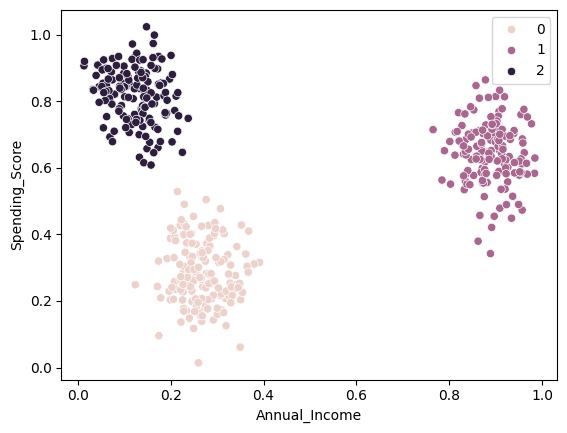

In [17]:
sns.scatterplot(data=pd.DataFrame(X_test_scaled, columns=X_test.columns), x="Annual_Income", y="Spending_Score", hue=y_pred)
plt.show()

In [18]:

## k değerini doğrulamanın alternatif yolları
## kneelocator

In [19]:
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable


In [20]:
from kneed import KneeLocator

In [21]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing") #make sure you specify convex or concave in curve

In [22]:
kl.elbow

np.int64(3)

In [24]:
# Diğer alternatif
# silhoutte score
from sklearn.metrics import silhouette_score

In [25]:
silhouette_coefficients=[]
for k in range(2,11): # En az 2 küme etiketine ihtiyaç var, bu yüzden 1 tane denemiyoruz.
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_) 
    silhouette_coefficients.append(score)

In [26]:
silhouette_coefficients

[np.float64(0.6499162948341466),
 np.float64(0.7866198110931956),
 np.float64(0.639598155184535),
 np.float64(0.511921250597414),
 np.float64(0.39752632041353236),
 np.float64(0.38326872643864596),
 np.float64(0.34664205911597173),
 np.float64(0.36232792515211165),
 np.float64(0.341721751439678)]

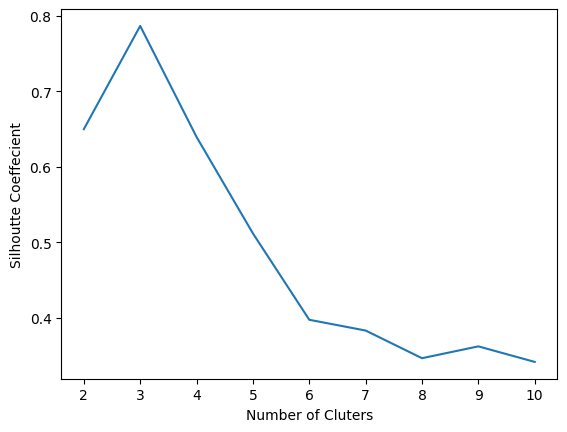

In [27]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()